# Cell 1 — Feature D: Price Tier Classification

## Objective

Develop a machine learning system that classifies Amazon products into price tiers:

- Budget
- Mid-range
- Premium

The classifier must predict the price tier using product attributes rather than the product's actual price.

## Key Constraint

The `price` column will be used only to derive the target price-tier labels.

The `price` column will never be used as a model input feature.

## Proposed Methodology

Because the dataset contains multiple heterogeneous product categories with substantially different price ranges, price tiers will initially be defined relative to products within the same `search_keyword`.

For each search keyword:

- Lower price segment → Budget
- Middle price segment → Mid-range
- Upper price segment → Premium

This methodology will be validated during exploratory data analysis.

## Workflow

1. Feature-specific data validation
2. Price distribution analysis
3. Price-tier label creation
4. Feature relationship analysis
5. Save prepared dataset for model development

In [2]:
#Cell 2 — Imports
from pathlib import Path
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [3]:
#Cell 3 — Define Project Paths
PROJECT_ROOT = Path.cwd().resolve()

print("Current working directory:")
print(PROJECT_ROOT)

Current working directory:
D:\AI_Trainning\Projects\Amazon_Marketplace_Product_Intelligence_Platform\notebooks\feature_d_price_tier


In [ ]:
"""#Cell 4A — Load Dataset (Google Colab)
from google.colab import drive

drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "Amazon_Marketplace_Product_Intelligence_Platform"
)

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cleaned_products.csv"
)

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully: {DATA_PATH}")
print(f"Shape: {df.shape}")

df.head()"""

In [8]:
#Cell 4B — Load Dataset (Local Jupyter)
current_path = Path.cwd().resolve()

PROJECT_ROOT = next(
    parent
    for parent in [current_path, *current_path.parents]
    if (parent / "src").exists()
    and (parent / "data").exists()
)

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cleaned_products.csv"
)

df = pd.read_csv(DATA_PATH)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset loaded successfully: {DATA_PATH}")
print(f"Shape: {df.shape}")
df.head()


Project root: D:\AI_Trainning\Projects\Amazon_Marketplace_Product_Intelligence_Platform
Dataset loaded successfully: D:\AI_Trainning\Projects\Amazon_Marketplace_Product_Intelligence_Platform\data\processed\cleaned_products.csv
Shape: (946, 17)


,product_number,asin,search_keyword,title,url,price,description,description_imputed,brand,image,review_count,average_rating,video_url,reviews,review_number_collected,title_length,description_length
0,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, ...",https://www.amazon.com/Wireless-Sports-Earbuds...,25.99,About this item\r\nSecure Fit for High-Intensi...,False,Csasan,https://m.media-amazon.com/images/I/613tyoH+sm...,9662,4.4,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""Needsmorenails"", ""star_rat...",8,196,2969
1,2,B0GFF3RCCL,wireless earbuds,TALIX T30 Noise Cancelling Earbuds with Phone ...,https://www.amazon.com/TALIX-Cancelling-Blueto...,25.99,About this item\r\n【Punchy Bass】 Featuring 10m...,False,TALIX,https://m.media-amazon.com/images/I/511IigIBpo...,67,4.3,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""Michelle"", ""star_rating"": ...",8,149,1544
2,3,B0HBWW3958,wireless earbuds,"Wireless Earbuds, Bluetooth 5.3 Headphones HiF...",https://www.amazon.com/Fhumsh-Bluetooth-Headph...,19.98,About this item\r\nSmart LED Display & 50H Spo...,False,Brand: Fhumsh,https://m.media-amazon.com/images/I/61D5ZCSIym...,196,5.0,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""Mary Santana"", ""star_ratin...",8,184,2127
3,4,B0H9LHWBDK,wireless earbuds,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphone...",https://www.amazon.com/Bluetooth-Headphones-Ca...,18.99,About this item\r\nLED Power Display and 50H P...,False,Brand: XIAOWTEK,https://m.media-amazon.com/images/I/61odQgshCW...,782,4.6,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""diamela"", ""star_rating"": 5...",8,195,2406
4,5,B0H7R1LD7B,wireless earbuds,"HAOYUYAN Wireless Earbuds, Sports Bluetooth He...",https://www.amazon.com/HAOYUYAN-Bluetooth-Head...,23.98,About this item\r\n【Sports Comfort & IPX7 Wate...,False,HAOYUYAN,https://m.media-amazon.com/images/I/71cmAChhQK...,371,4.6,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""Shigo"", ""star_rating"": 5.0...",5,181,2501


In [9]:
#Cell 5 — Feature D Data Audit
FEATURE_D_COLUMNS = [
    "title",
    "description",
    "brand",
    "price",
    "review_count",
    "average_rating",
    "review_number_collected",
    "title_length",
    "description_length",
]

audit_df = pd.DataFrame({
    "dtype": df[FEATURE_D_COLUMNS].dtypes.astype(str),
    "missing_count": df[FEATURE_D_COLUMNS].isna().sum(),
    "missing_percent": (
        df[FEATURE_D_COLUMNS].isna().mean() * 100
    ).round(2),
    "unique_values": df[FEATURE_D_COLUMNS].nunique(),
})

print("=" * 80)
print("FEATURE D DATA AUDIT")
print("=" * 80)

display(audit_df)

print("\nPrice summary:")
display(df["price"].describe())

print(f"\nProducts with price <= 0: {(df['price'] <= 0).sum()}")
print(f"Duplicate ASINs: {df['asin'].duplicated().sum()}")
print(f"Unique search keywords: {df['search_keyword'].nunique()}")

FEATURE D DATA AUDIT


,dtype,missing_count,missing_percent,unique_values
title,str,0,0.0,895
description,str,0,0.0,882
brand,str,0,0.0,436
price,float64,0,0.0,483
review_count,int64,0,0.0,785
average_rating,float64,0,0.0,17
review_number_collected,int64,0,0.0,8
title_length,int64,0,0.0,166
description_length,int64,0,0.0,716



Price summary:


count     946.000000
mean       79.388568
std       115.299683
min         2.970000
25%        18.717500
50%        35.850000
75%        94.702500
max      1296.950000
Name: price, dtype: float64


Products with price <= 0: 0
Duplicate ASINs: 0
Unique search keywords: 28


GLOBAL PRICE DISTRIBUTION


count     946.000000
mean       79.388568
std       115.299683
min         2.970000
25%        18.717500
50%        35.850000
75%        94.702500
max      1296.950000
Name: price, dtype: float64

C:\Users\bjit\AppData\Local\Temp\ipykernel_15976\903138747.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df["price"], vert=False)


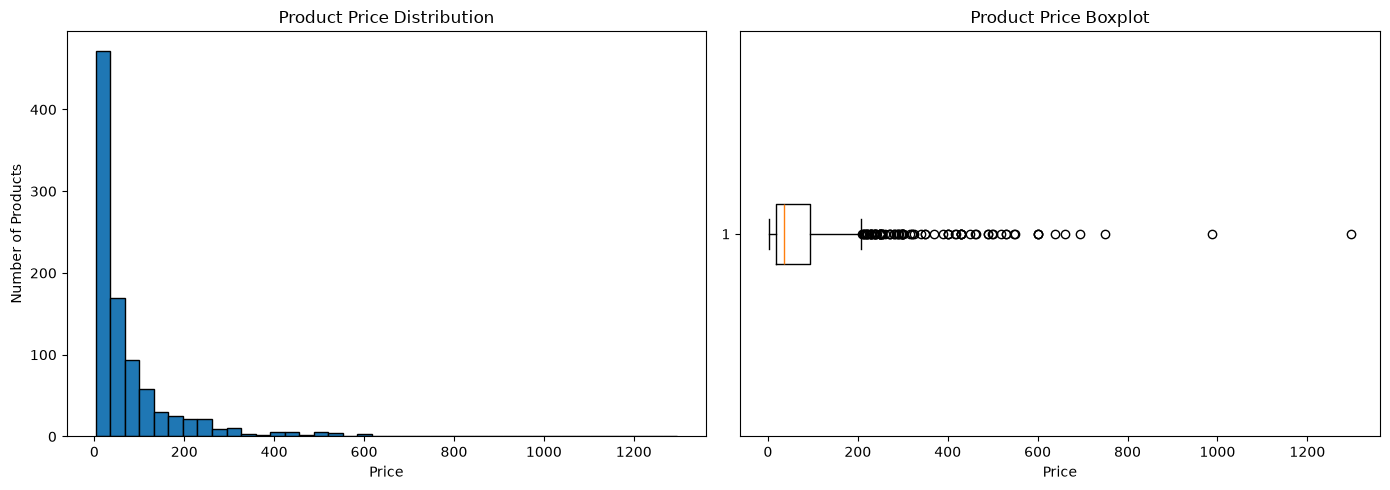

In [10]:
#Cell 6 — Global Price Distribution
print("=" * 80)
print("GLOBAL PRICE DISTRIBUTION")
print("=" * 80)

display(df["price"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["price"], bins=40, edgecolor="black")
axes[0].set_title("Product Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Number of Products")

axes[1].boxplot(df["price"], vert=False)
axes[1].set_title("Product Price Boxplot")
axes[1].set_xlabel("Price")

plt.tight_layout()
plt.show()

In [11]:
#Cell 7 — Price Distribution by Search Keyword
keyword_price_summary = (
    df.groupby("search_keyword")["price"]
    .agg(
        product_count="count",
        min_price="min",
        median_price="median",
        mean_price="mean",
        max_price="max",
        std_price="std",
        unique_prices="nunique",
    )
    .sort_values("median_price")
)

display(keyword_price_summary)

,product_count,min_price,median_price,mean_price,max_price,std_price,unique_prices
search_keyword,,,,,,,
phone stand,21,6.99,9.990,12.561905,22.99,4.600025,15
notebook journal,57,2.97,9.990,12.966842,32.99,7.036455,34
phone case,16,6.99,14.485,15.327500,30.00,6.024050,13
t-shirt,60,6.43,14.990,15.930333,39.99,7.420143,40
sunglasses,48,6.98,15.990,61.340417,296.00,93.315626,36
candle,59,9.99,19.990,25.822881,125.00,20.250719,44
wireless earbuds,27,8.18,20.990,38.238148,249.99,48.399940,19
portable charger,22,18.98,22.490,38.390909,279.99,55.256206,16
USB-C hub,22,8.94,23.585,31.065455,79.99,18.305100,18


C:\Users\bjit\AppData\Local\Temp\ipykernel_15976\1741913979.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


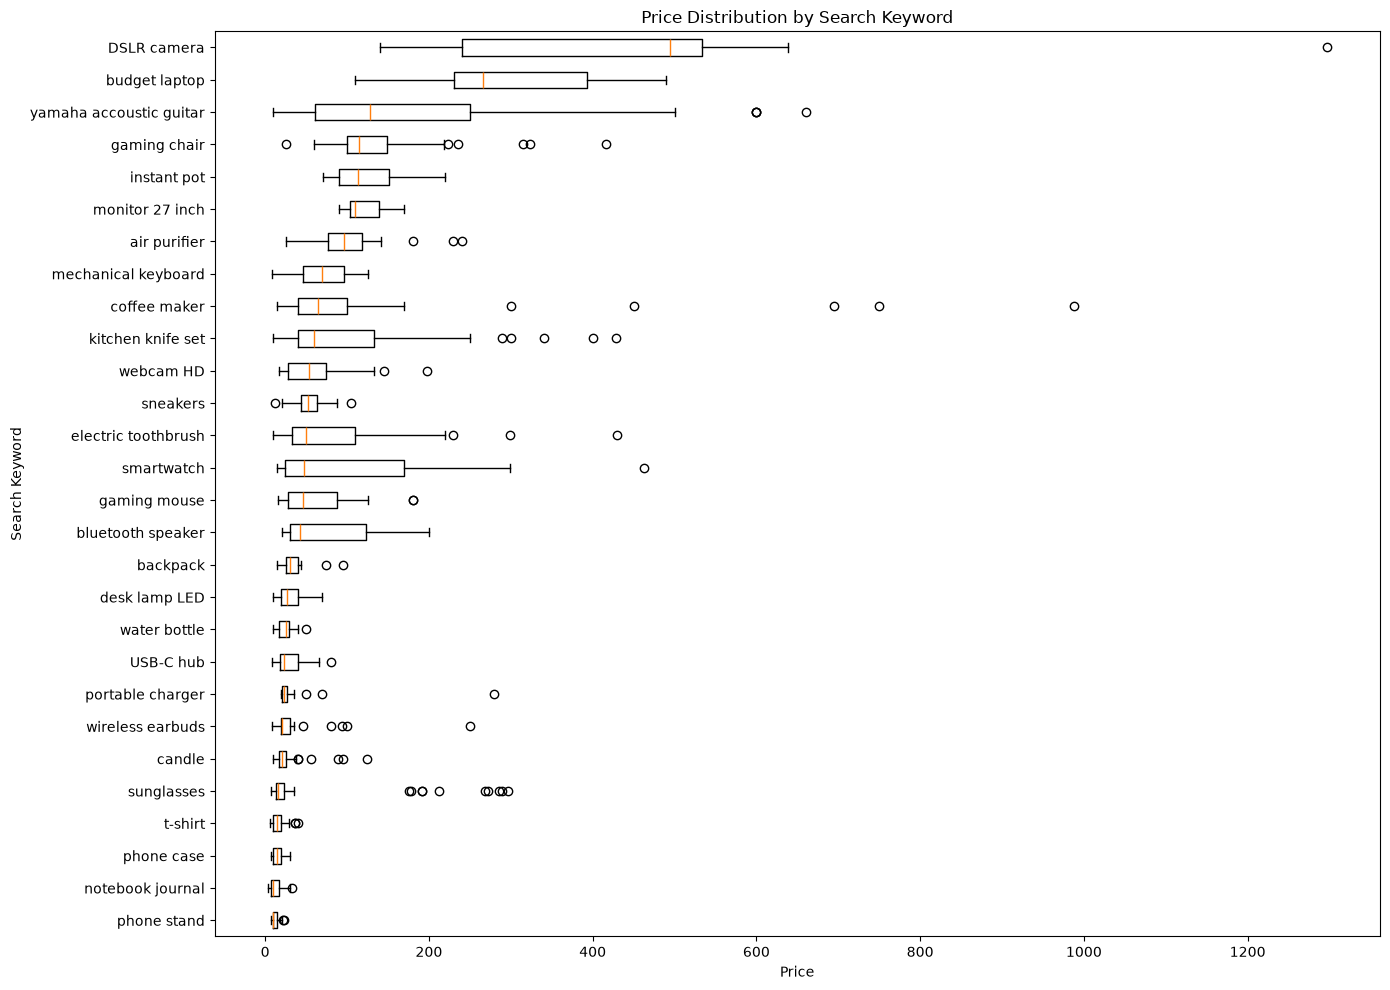

In [13]:
#Cell 8 — Visual Category Price Comparison
keyword_order = (
    df.groupby("search_keyword")["price"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(14, 10))

data_to_plot = [
    df.loc[df["search_keyword"] == keyword, "price"]
    for keyword in keyword_order
]

plt.boxplot(
    data_to_plot,
    tick_labels=keyword_order,
    vert=False,
)

plt.title("Price Distribution by Search Keyword")
plt.xlabel("Price")
plt.ylabel("Search Keyword")

plt.tight_layout()
plt.show()

In [20]:
# Cell 9 — Create Category-Relative Price Tier Labels (Fixed)
def assign_price_tier(df_in):
    df_out = df_in.copy()
    
    # Calculate 33rd and 67th percentiles per group
    q1 = df_out.groupby("search_keyword")["price"].transform(lambda x: x.quantile(0.33))
    q2 = df_out.groupby("search_keyword")["price"].transform(lambda x: x.quantile(0.67))
    
    # Assign tiers
    df_out["price_tier"] = np.where(
        df_out["price"] <= q1, "budget",
        np.where(df_out["price"] <= q2, "mid_range", "premium")
    )
    return df_out

feature_d_df = assign_price_tier(df)

print("Price tier labels created successfully.")
feature_d_df[["search_keyword", "price", "price_tier"]].head(5)

Price tier labels created successfully.


,search_keyword,price,price_tier
0,wireless earbuds,25.99,mid_range
1,wireless earbuds,25.99,mid_range
2,wireless earbuds,19.98,budget
3,wireless earbuds,18.99,budget
4,wireless earbuds,23.98,mid_range


In [17]:
#Cell 10 — Validate Overall Class Distribution
tier_distribution = (
    feature_d_df["price_tier"]
    .value_counts()
    .rename_axis("price_tier")
    .reset_index(name="count")
)

tier_distribution["percentage"] = (
    tier_distribution["count"]
    / len(feature_d_df)
    * 100
).round(2)

display(tier_distribution)

,price_tier,count,percentage
0,budget,327,34.57
1,mid_range,314,33.19
2,premium,305,32.24


In [21]:
#Cell 11 — Validate Tier Distribution Per Search Keyword
tier_by_keyword = pd.crosstab(
    feature_d_df["search_keyword"],
    feature_d_df["price_tier"],
)

tier_by_keyword["total"] = tier_by_keyword.sum(axis=1)

display(tier_by_keyword)

price_tier,budget,mid_range,premium,total
search_keyword,,,,
DSLR camera,5,7,4,16
USB-C hub,7,10,5,22
air purifier,5,6,5,16
backpack,5,6,5,16
bluetooth speaker,5,6,5,16
budget laptop,7,8,7,22
candle,21,18,20,59
coffee maker,18,14,16,48
desk lamp LED,23,16,19,58


In [22]:
#Cell 12 — Numeric Features by Price Tier
NUMERIC_FEATURES = [
    "review_count",
    "average_rating",
    "review_number_collected",
    "title_length",
    "description_length",
]

numeric_summary = (
    feature_d_df
    .groupby("price_tier", observed=True)[NUMERIC_FEATURES]
    .agg(["mean", "median"])
    .round(2)
)

display(numeric_summary)

review_count         average_rating        review_number_collected  \
                   mean  median           mean median                    mean   
price_tier                                                                      
budget         10895.19  2190.0           4.48    4.5                    7.93   
mid_range      19939.06  2389.5           4.47    4.5                    7.93   
premium        11208.61  1507.0           4.49    4.5                    7.90   

                  title_length        description_length          
           median         mean median               mean  median  
price_tier                                                        
budget        8.0        153.5  178.0            1194.14  1125.0  
mid_range     8.0        146.1  170.5            1167.48  1134.5  
premium       8.0        143.9  170.0            1136.45  1113.0

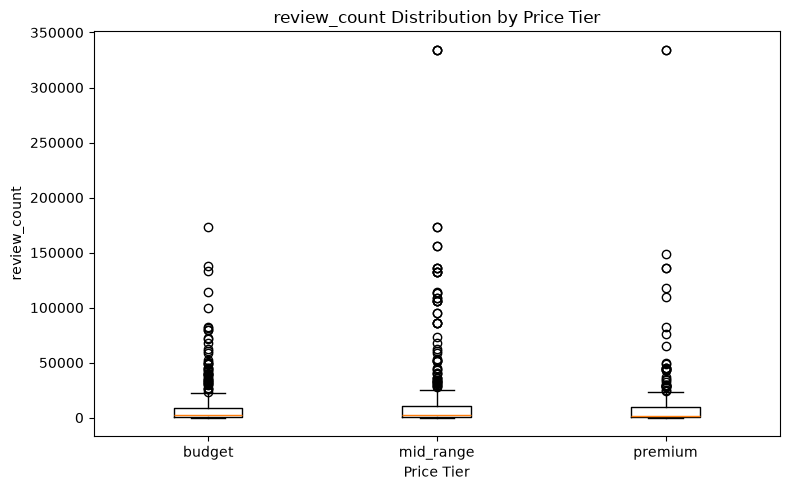

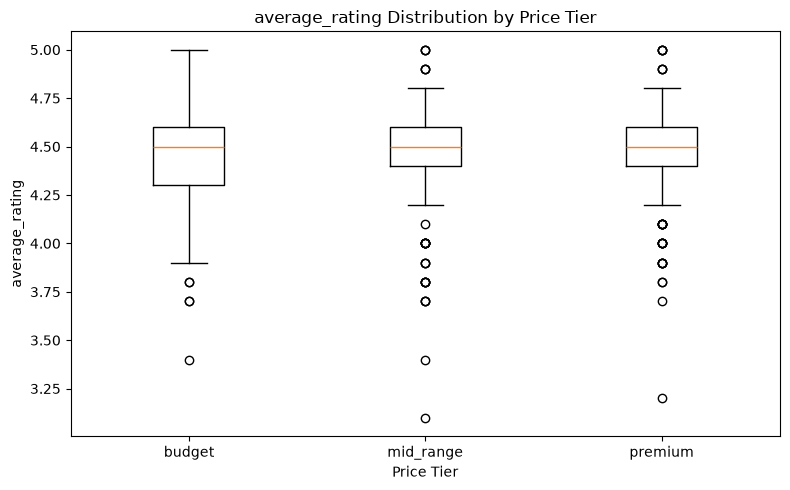

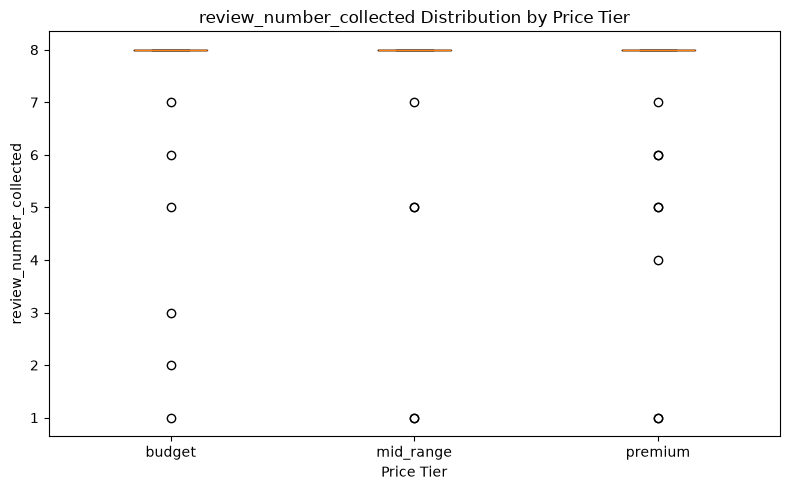

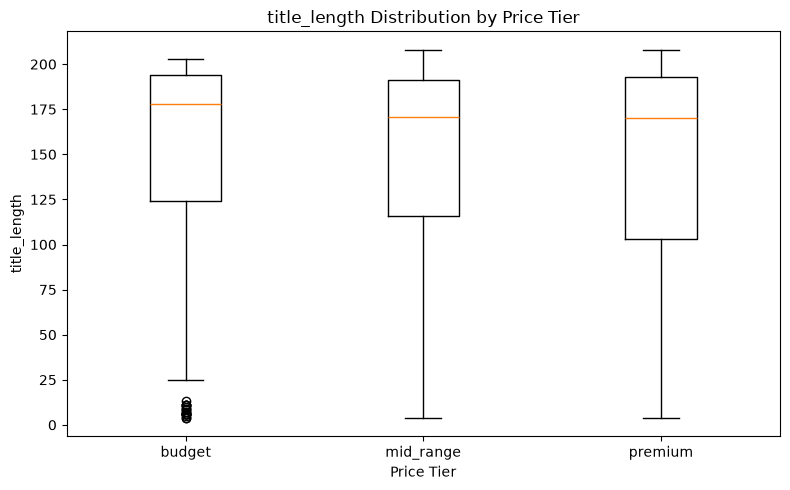

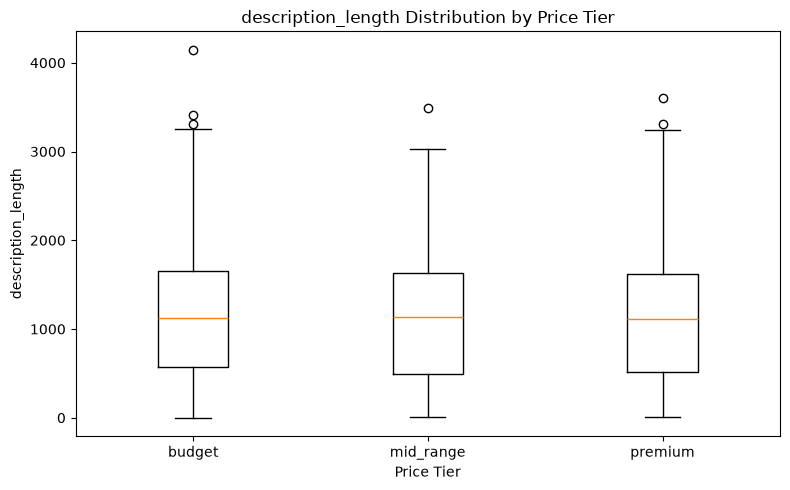

In [24]:
#Cell 13 — Visualize Numeric Feature Relationships
for feature in NUMERIC_FEATURES:
    plt.figure(figsize=(8, 5))

    tier_order = ["budget", "mid_range", "premium"]

    data_to_plot = [
        feature_d_df.loc[
            feature_d_df["price_tier"] == tier,
            feature
        ]
        for tier in tier_order
    ]

    plt.boxplot(
        data_to_plot,
        tick_labels=tier_order,
    )

    plt.title(f"{feature} Distribution by Price Tier")
    plt.xlabel("Price Tier")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

## Numeric metadata alone probably won't classify tiers strongly

In [26]:
#Cell 14 — Top Brands and Their Price-Tier Distribution
brand_tier_counts = pd.crosstab(
    feature_d_df["brand"],
    feature_d_df["price_tier"],
)

brand_product_counts = feature_d_df["brand"].value_counts()

# Focus on brands with at least 3 products
brands_to_display = brand_product_counts[
    brand_product_counts >= 3
].index

brand_tier_display = (
    brand_tier_counts
    .loc[brands_to_display]
    .copy()
)

brand_tier_display["total"] = brand_tier_display.sum(axis=1)

brand_tier_display = (
    brand_tier_display
    .sort_values("total", ascending=False)
)

display(brand_tier_display.head(20))

price_tier,budget,mid_range,premium,total
brand,,,,
No Brand,23,50,89,162
Oral-B,3,10,5,18
Philips Sonicare,4,5,9,18
Instant Pot,4,5,5,14
Keurig,3,6,3,12
Amazon Renewed,4,7,0,11
Gildan,2,6,3,11
Skechers,2,4,5,11
GTPLAYER,0,8,2,10


In [27]:
#Cell 15 — Label Sanity Check
tier_order = ["budget", "mid_range", "premium"]

for tier in tier_order:
    print("\n" + "=" * 100)
    print(f"{tier.upper()} PRODUCT EXAMPLES")
    print("=" * 100)

    sample = (
        feature_d_df[
            feature_d_df["price_tier"] == tier
        ]
        .sample(
            n=5,
            random_state=42,
        )
        [["search_keyword", "title", "brand", "price"]]
    )

    display(sample)


BUDGET PRODUCT EXAMPLES


,search_keyword,title,brand,price
676,notebook journal,"Taja Hardcover Journal for Women, Pretty Spira...",Taja,6.99
323,budget laptop,"Dell Chromebook 11 3100 11.6"" Chromebook - 136...",Amazon Renewed,109.99
743,sneakers,Skechers Women's Summits Quick Getaway | Memor...,Skechers,32.59
25,wireless earbuds,"Bluetooth 5.3 True Wireless Earbuds, Wireless ...",Brand: CPTEA,9.99
264,electric toothbrush,7AM2M Sonic Electric Toothbrush for Adults | 6...,7AM2M,9.99



MID_RANGE PRODUCT EXAMPLES


,search_keyword,title,brand,price
386,kitchen knife set,McCook Knife Set Sharp Kitchen Knife Block Set...,McCook,57.98
95,smartwatch,"Smart Watch for Women, Answer/Make Call, 1.32'...",aeac,64.98
649,t-shirt,COOFANDY Mens T-Shirts Summer Crew Neck Casual...,COOFANDY,14.99
158,webcam HD,Logitech C920e HD 1080p Mic Enabled Webcam Cer...,No Brand,68.49
750,sneakers,Reebok Club C Extra Platform Sneakers for Wome...,Reebok,57.75



PREMIUM PRODUCT EXAMPLES


,search_keyword,title,brand,price
568,water bottle,Under Armour Insulated Water Bottle with Handl...,No Brand,28.00
490,gaming chair,ELABEST X100 Ergonomic Mesh Office Chair with ...,ELABEST,323.99
351,kitchen knife set,"Yatoshi Professional Kitchen Knife Set, 15 Pie...",Yatoshi Knives,199.98
771,candle,"AOOVOO Fall Scented Candles - 6 PC Soy Candle,...",AOOVOO,26.99
194,desk lamp LED,"Quntis Computer Monitor Lamp, Screen Monitor L...",Quntis,39.95


# Cell 16 — Key EDA Findings

### 1. Price distribution is highly heterogeneous

Product prices range from approximately $2.97 to $1,296.95. The distribution is strongly right-skewed, with a median price of $35.85 and a mean price of $79.39.

Price ranges differ substantially between search keywords. Therefore, global price thresholds would produce misleading price tiers across unrelated product types.

### 2. Category-relative price tiers were selected

Price tiers were created independently within each `search_keyword` using the 33rd and 67th price percentiles:

- Budget: lower price segment
- Mid-range: middle price segment
- Premium: upper price segment

This produces a balanced target distribution:

- Budget: 34.57%
- Mid-range: 33.19%
- Premium: 32.24%

The tiers represent relative market positioning within a product group rather than absolute universal price ranges.

### 3. Numeric metadata shows limited standalone separation

Average rating, number of collected reviews, title length, and description length show relatively small differences between price tiers.

Review count shows some variation, although its distribution is highly skewed and affected by large outliers.

This suggests that numeric metadata alone may have limited predictive power.

### 4. Text and brand information may provide useful signals

Product titles and descriptions contain information about product specifications, features, materials, and positioning that may correlate with relative price tiers.

Brand may also provide useful information, but the dataset contains high brand cardinality. Therefore, model development will compare text-based and hybrid approaches rather than relying heavily on one-hot encoded brands.

### Modeling Implication

The next stage will compare multiple approaches:

1. Numeric metadata baseline
2. TF-IDF text classification
3. Hybrid text + numeric feature classification

The actual product price will not be used as an input feature in any model.

In [29]:
#Cell 17 — Final Feature D Dataset Validation
id_columns = [
    "product_number",
    "asin",
    "url",
    "image",
    "video_url",
    "reviews",
]

target_column = "price_tier"

print("=" * 80)
print("FEATURE D PREPARED DATASET VALIDATION")
print("=" * 80)

print(f"Dataset shape: {feature_d_df.shape}")
print(f"Target column: {target_column}")
print(f"Price column available for label audit: {'price' in feature_d_df.columns}")

print("\nTarget distribution:")
print(feature_d_df[target_column].value_counts())

assert feature_d_df[target_column].isna().sum() == 0
assert feature_d_df["price"].isna().sum() == 0
assert set(feature_d_df[target_column].unique()) == {
    "budget",
    "mid_range",
    "premium",
}

print("\nFeature D prepared dataset validation passed.")
print(
    "IMPORTANT: 'price' is retained for auditability "
    "but will be explicitly excluded from all model inputs."
)

FEATURE D PREPARED DATASET VALIDATION
Dataset shape: (946, 18)
Target column: price_tier
Price column available for label audit: True

Target distribution:
price_tier
budget       327
mid_range    314
premium      305
Name: count, dtype: int64

Feature D prepared dataset validation passed.
IMPORTANT: 'price' is retained for auditability but will be explicitly excluded from all model inputs.


In [ ]:
"""#Cell 18A — Save Dataset (Google Colab)
OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = (
    OUTPUT_DIR
    / "feature_d_price_tier_dataset.csv"
)

feature_d_df.to_csv(
    OUTPUT_PATH,
    index=False,
)

print(f"Saved successfully to:\n{OUTPUT_PATH}")
print(f"Dataset shape: {feature_d_df.shape}")"""

In [31]:
#Cell 18B — Save Dataset
OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = (
    OUTPUT_DIR
    / "feature_d_price_tier_dataset.csv"
)

feature_d_df.to_csv(
    OUTPUT_PATH,
    index=False,
)

print(f"Saved successfully to:\n{OUTPUT_PATH}")
print(f"Dataset shape: {feature_d_df.shape}")

Saved successfully to:
D:\AI_Trainning\Projects\Amazon_Marketplace_Product_Intelligence_Platform\data\processed\feature_d_price_tier_dataset.csv
Dataset shape: (946, 18)


In [32]:
#Cell 19 — Reload Verification
reloaded_df = pd.read_csv(OUTPUT_PATH)

print("=" * 80)
print("RELOAD VERIFICATION")
print("=" * 80)

print(f"Original shape: {feature_d_df.shape}")
print(f"Reloaded shape: {reloaded_df.shape}")

assert feature_d_df.shape == reloaded_df.shape
assert "price_tier" in reloaded_df.columns
assert reloaded_df["price_tier"].isna().sum() == 0

print("\nReloaded target distribution:")
print(reloaded_df["price_tier"].value_counts())

print("\n✓ Feature D dataset successfully saved and reloaded.")

RELOAD VERIFICATION
Original shape: (946, 18)
Reloaded shape: (946, 18)

Reloaded target distribution:
price_tier
budget       327
mid_range    314
premium      305
Name: count, dtype: int64

✓ Feature D dataset successfully saved and reloaded.
